🔄 ch10 > sec02 > 01_conditional_tools.ipynb 예제 재사용 하기

#### hello 도구 테스트

In [2]:
# https://github.com/langchain-ai/langchain-mcp-adapters?tab=readme-ov-file#streamable-http

from mcp import ClientSession
from mcp.client.streamable_http import streamablehttp_client

from langchain_mcp_adapters.tools import load_mcp_tools

async with streamablehttp_client("http://127.0.0.1:8000/mcp/") as (read, write, _):
    async with ClientSession(read, write) as session:
        await session.initialize()

        # Get tools
        tools = await load_mcp_tools(session)

        # 'hello' 도구를 비동기적으로 실행하고 결과를 result 변수에 할당
        # MCP는 서버이기 때문에 네트워크로 비동기 통신함
        result = await tools[0].ainvoke({"name": "김일남"})
        print(result)


안녕하세요, 김일남님!


#### 랭그래프에서 MCP 연동

> Use MCP: <https://langchain-ai.github.io/langgraph/agents/mcp/#use-mcp-tools> </br>
> GitHub: <https://github.com/langchain-ai/langchain-mcp-adapters?tab=readme-ov-file#using-with-langgraph-stategraph>

In [3]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "mcp_tools": {
            "url": "http://localhost:8000/mcp/",
            "transport": "streamable_http",
        }
    }
)
tools = await client.get_tools()

In [4]:
tools

[StructuredTool(name='hello', description='간단한 인사말을 반환하는 도구', args_schema={'properties': {'name': {'default': '아무개', 'title': 'Name', 'type': 'string'}}, 'title': 'helloArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x1236f9940>),
 StructuredTool(name='get_current_time', description="현재 시각을 반환하는 함수\n\nArgs:\n    timezone (str): 타임존 (예: 'Asia/Seoul') 실제 존재하는 타임존이어야 함\n    location (str): 지역명. 타임존이 모든 지명에 대응되지 않기 때문에 이후 llm 답변 생성에 사용됨\n", args_schema={'properties': {'timezone': {'default': 'Asia/Seoul', 'title': 'Timezone', 'type': 'string'}, 'location': {'default': '부산', 'title': 'Location', 'type': 'string'}}, 'title': 'get_current_timeArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x1236faa20>),
 StructuredTool(name='get_yf_stock_history', description='주식 종목의 가격 데이터를 조회하는 함수', args_sche

In [5]:
result = await tools[0].ainvoke({"name": "김일남"})
result

'안녕하세요, 김일남님!'

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [38]:
# from langchain.chat_models import init_chat_model # 다양한 언어 모델을 단일 함수로 초기화
# from dotenv import load_dotenv
# load_dotenv()

# model = init_chat_model("gemini-2.5-flash", model_provider="google_genai")

In [7]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph.message import add_messages

# 상태 정의
class State(TypedDict):	
    messages: Annotated[list[str], add_messages]

In [8]:
# * 도구 바인딩
def call_model(state: State):
    response = model.bind_tools(tools).invoke(state["messages"])
    return {"messages": response}

In [9]:
from langgraph.graph import START, END

def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 END로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
        
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [10]:
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode

# 그래프 구성
graph_builder = StateGraph(State)

graph_builder.add_node(call_model)
graph_builder.add_node(ToolNode(tools))
graph_builder.add_edge(START, "call_model")
graph_builder.add_conditional_edges(
    "call_model",
    route_tools,
    {"tools": "tools", END: END},
)
graph_builder.add_edge("tools", "call_model")
graph = graph_builder.compile()

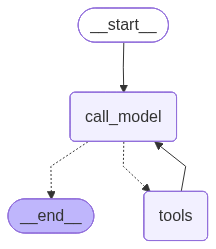

In [11]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [12]:
time_response = await graph.ainvoke({"messages": "지금 부산 몇시야?"})
time_response

{'messages': [HumanMessage(content='지금 부산 몇시야?', additional_kwargs={}, response_metadata={}, id='73df5d40-f47e-4655-90ba-936cc8c2307b'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_current_time', 'arguments': '{"timezone": "Asia/Seoul", "location": "\\ubd80\\uc0b0"}'}, '__gemini_function_call_thought_signatures__': {'628ddef4-9748-43b5-894e-163f495871c4': 'Cr4HAXLI2nzkEgQaVHz82GTxY/2LnuDXtep/h5Y9mMNt5FKR7nTA+GJwnPC2trvpq18/7pBE9m+pH+4mMBSXkST9S2GqoAlLultOaVZEIEgczFGDk6ysfGhpHOgOFN4Htw8Hr1UwdZlHi6I5SHIYbd1sQsRMO0wxHXkxVool1srfB8iCn1ytn/c9OOVIi2guLuMyshKib/zQeCVNibua+zN8DPD8waH5u15yxS3hn0X8at4Q5BUHy48yNEZRagZU7SDKIebCQBojWNVxFA5nXS+E4ydFNw4Yma0GPenL4z3jeT34ADNx1nVy7mX5fJSpcnHXwmaqCG1qqb4MXADjKDUvvKTV7PadztKlpsuuzRrIU2oXSTrx+oy6YJfesH4LGBajIGOH6Du7xSB5okYIV8XMvgBEFex4ZxDihXXHZ/AjkPJIJe9c7T6rdpsveB3co9wtA/L0mNkJGpdYED0R97o/iSOGp5wA1Rr+3KUJrpAytv7cEkE6GXwnvzc7QTiKNqp13gnIBhwC6oD5WjgVxofali06g9HYLCDvpIoHxVSv+ElQqKHpwfKQvPZJItrqy8LTvlB3FeqTGISIATYM8p+0uIOV53mTR23

In [15]:
stock_response = await graph.ainvoke({"messages": "테슬라 주가는 한달 전 보다 올랐나 내렸나?"})
stock_response


{'messages': [HumanMessage(content='테슬라 주가는 한달 전 보다 올랐나 내렸나?', additional_kwargs={}, response_metadata={}, id='83bf35eb-51d6-4e26-abd3-d32fa08ed450'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_yf_stock_history', 'arguments': '{"stock_history_input": {"ticker": "TSLA", "period": "1mo"}}'}, '__gemini_function_call_thought_signatures__': {'22c453f7-b492-42a8-8bad-cb166e038426': 'CtoDAXLI2nwksn/aJ+FF2dOn8OtmJd3zQL8GqUTX8aL6afKM/8N7wdt6ey1LvldZG4udOvUHyBLUEA9XdxamD7CWqh3baVe+W52aCc395CwH2vI7IXJxx2zXOUldKJ04cxT3rwTFDjVieh2/rtI8iX1NzNvpGVdOKAwWueNEO1xyV9K0/RHfYRw1qD4oxh2DzO17oeY6eiLDH9B+PsW3JxVQbMH+a9nO910q9EfaoE/jEvj/dnbS9D1lN7rL5Ud1iuvZWMlesr76Sn1jgIczHzLsfLsr/EAfQScx/g09X5X6TrMU+wtxnub4a7p/4BWao2V+MwxPZLya2YyqJRPPUr8WIPJ2FF65e2kL8PPg/RyXcfpPdSexQVvN5LCWg4TU92JRc4D9NRPZtqRp1srtP9C6OPG2BKSzbadIYfQdD6iaIfhtMBXpO8aaqx+5eBw4uVQ56CPzPp/juKaAFhUSa6jh1xx3s2yuBxKOCcQT7qjLlxcAiuytnVw7aRUfMdbVpcmZOnGyRdPeVeuZIrU+59f3XUGd17P8YLRg3Gvsy8slzK9g5YHK0T2x6Ni6EJMCLlOf5f9JLTGta